In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

In [6]:
df.head()

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease
0,56,Male,26.6,140,277,75,55,No,Moderate,Disease
1,69,Male,29.8,165,215,115,61,No,Low,No Disease
2,46,Male,24.1,128,189,77,50,No,Low,No Disease
3,32,Male,31.8,101,185,120,90,No,Moderate,No Disease
4,60,Male,27.0,170,201,122,76,Yes,Moderate,Disease


In [7]:
df.tail()

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease
2995,68,Female,32.6,165,227,77,76,No,Low,No Disease
2996,32,Male,25.4,126,159,140,78,No,Moderate,No Disease
2997,21,Male,28.9,112,176,108,67,No,Low,No Disease
2998,38,Female,32.6,110,223,100,72,No,High,No Disease
2999,30,Female,24.6,125,179,127,60,Yes,High,No Disease


In [8]:
df.shape

(3000, 10)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  3000 non-null   int64  
 1   Gender               3000 non-null   str    
 2   BMI                  3000 non-null   float64
 3   Blood_Pressure_mmHg  3000 non-null   int64  
 4   Cholesterol_mg_dL    3000 non-null   int64  
 5   Glucose_mg_dL        3000 non-null   int64  
 6   Heart_Rate_bpm       3000 non-null   int64  
 7   Smoking              3000 non-null   str    
 8   Exercise_Level       3000 non-null   str    
 9   Disease              3000 non-null   str    
dtypes: float64(1), int64(5), str(4)
memory usage: 298.9 KB


In [10]:
df.isnull().sum()

Age                    0
Gender                 0
BMI                    0
Blood_Pressure_mmHg    0
Cholesterol_mg_dL      0
Glucose_mg_dL          0
Heart_Rate_bpm         0
Smoking                0
Exercise_Level         0
Disease                0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

Age                    0.0
Gender                 0.0
BMI                    0.0
Blood_Pressure_mmHg    0.0
Cholesterol_mg_dL      0.0
Glucose_mg_dL          0.0
Heart_Rate_bpm         0.0
Smoking                0.0
Exercise_Level         0.0
Disease                0.0
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[df.duplicated()]

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease


In [15]:
import pandas as pd

# Assuming your dataset is loaded into a DataFrame named 'df'
# df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# 1. Identify numerical columns (integers and floats)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Identify categorical columns (objects/strings and categories)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 'Glucose_mg_dL', 'Heart_Rate_bpm']
Categorical Columns: ['Gender', 'Smoking', 'Exercise_Level', 'Disease']


In [17]:
import pandas as pd

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Print unique values and count distribution for each column
for col in categorical_cols:
    print(f"=== {col} ===")
    print("Unique Values:", df[col].unique())
    print("Counts:")
    print(df[col].value_counts())
    print("-" * 30)

=== Gender ===
Unique Values: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Counts:
Gender
Male      1573
Female    1427
Name: count, dtype: int64
------------------------------
=== Smoking ===
Unique Values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Counts:
Smoking
No     2169
Yes     831
Name: count, dtype: int64
------------------------------
=== Exercise_Level ===
Unique Values: <ArrowStringArray>
['Moderate', 'Low', 'High']
Length: 3, dtype: str
Counts:
Exercise_Level
Moderate    1359
Low         1091
High         550
Name: count, dtype: int64
------------------------------
=== Disease ===
Unique Values: <ArrowStringArray>
['Disease', 'No Disease']
Length: 2, dtype: str
Counts:
Disease
No Disease    2298
Disease        702
Name: count, dtype: int64
------------------------------


In [18]:
import pandas as pd

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# Select all string/object columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Clean whitespace and convert to Title Case across all categorical columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [19]:
# Define mapping dictionaries for inconsistent categories
gender_fix = {
    'm': 'Male', 'male': 'Male', 'MALE': 'Male', 'Male ': 'Male',
    'f': 'Female', 'female': 'Female', 'FEMALE': 'Female'
}

smoking_fix = {
    'y': 'Yes', 'yes': 'Yes', 'YES': 'Yes', 'smoker': 'Yes',
    'n': 'No', 'no': 'No', 'NO': 'No', 'non-smoker': 'No'
}

exercise_fix = {
    'mod': 'Moderate', 'moderate': 'Moderate',
    'lo': 'Low', 'low': 'Low',
    'hi': 'High', 'high': 'High'
}

# Apply replacements
df['Gender'] = df['Gender'].replace(gender_fix)
df['Smoking'] = df['Smoking'].replace(smoking_fix)
df['Exercise_Level'] = df['Exercise_Level'].replace(exercise_fix)

In [20]:
def clean_categorical_column(series, mapping_dict=None):
    """
    Strips whitespace, standardizes title case, and applies optional dictionary mapping.
    """
    # 1. Remove leading/trailing spaces and fix capitalization
    cleaned = series.astype(str).str.strip().str.title()
    
    # 2. Apply dictionary mapping if provided
    if mapping_dict:
        cleaned = cleaned.replace(mapping_dict)
        
    return cleaned

# Example usage on your dataset columns
df['Gender'] = clean_categorical_column(df['Gender'])
df['Smoking'] = clean_categorical_column(df['Smoking'])
df['Exercise_Level'] = clean_categorical_column(df['Exercise_Level'])

# Verify unique values after cleaning
for col in ['Gender', 'Smoking', 'Exercise_Level', 'Disease']:
    print(col, "-> Unique values:", df[col].unique())

Gender -> Unique values: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Smoking -> Unique values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Exercise_Level -> Unique values: <ArrowStringArray>
['Moderate', 'Low', 'High']
Length: 3, dtype: str
Disease -> Unique values: <ArrowStringArray>
['Disease', 'No Disease']
Length: 2, dtype: str


In [21]:
import difflib

def fix_typos_fuzzy(series, standard_categories, cutoff=0.6):
    """
    Matches dirty string entries to the closest standard category name.
    """
    def match_val(val):
        matches = difflib.get_close_matches(str(val), standard_categories, n=1, cutoff=cutoff)
        return matches[0] if matches else val

    return series.apply(match_val)

# Define standard valid names
valid_exercise = ['Low', 'Moderate', 'High']

# Automatically fix typos like 'Moderat', 'Loww', 'Hihg'
df['Exercise_Level'] = fix_typos_fuzzy(df['Exercise_Level'], valid_exercise)

In [22]:
import pandas as pd
import numpy as np

# 1. Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# Define numerical columns
num_cols = ['Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 'Glucose_mg_dL', 'Heart_Rate_bpm']

# Convert non-numeric values to NaN (if any text got mixed into numerical columns)
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- CHECK 1: Missing, Infinite, Negative, and Zero Values ---
print("=" * 60)
print("1. GENERAL NUMERICAL ANOMALY REPORT")
print("=" * 60)

anomaly_report = []

for col in num_cols:
    nulls = df[col].isnull().sum()
    infs = np.isinf(df[col]).sum()
    negatives = (df[col] < 0).sum()
    zeros = (df[col] == 0).sum()
    
    anomaly_report.append({
        'Column': col,
        'Nulls/NaNs': nulls,
        'Infs': infs,
        'Negative Values': negatives,
        'Zero Values': zeros,
        'Min Value': df[col].min(),
        'Max Value': df[col].max()
    })

report_df = pd.DataFrame(anomaly_report)
print(report_df.to_string(index=False))

# --- CHECK 2: Domain-Specific Medical Range Checks ---
print("\n" + "=" * 60)
print("2. DOMAIN BOUNDARY VIOLATIONS")
print("=" * 60)

# Realistic clinical bounds for medical data
medical_bounds = {
    'Age': (0, 120),
    'BMI': (10.0, 70.0),
    'Blood_Pressure_mmHg': (40, 250),
    'Cholesterol_mg_dL': (50, 600),
    'Glucose_mg_dL': (30, 500),
    'Heart_Rate_bpm': (30, 220)
}

invalid_found = False
for col, (min_valid, max_valid) in medical_bounds.items():
    invalid_rows = df[(df[col] < min_valid) | (df[col] > max_valid)]
    if len(invalid_rows) > 0:
        invalid_found = True
        print(f"⚠️ Column '{col}' has {len(invalid_rows)} values outside valid range [{min_valid}, {max_valid}]")

if not invalid_found:
    print("✅ All values fall within standard realistic medical boundaries!")

# --- CHECK 3: Statistical Outliers (Interquartile Range Method) ---
print("\n" + "=" * 60)
print("3. STATISTICAL OUTLIERS DETECTED (IQR Method)")
print("=" * 60)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} statistical outliers found (Bounds: {lower_bound:.1f} to {upper_bound:.1f})")

1. GENERAL NUMERICAL ANOMALY REPORT
             Column  Nulls/NaNs  Infs  Negative Values  Zero Values  Min Value  Max Value
                Age           0     0                0            0       18.0       80.0
                BMI           0     0                0            0       16.0       41.1
Blood_Pressure_mmHg           0     0                0            0       90.0      180.0
  Cholesterol_mg_dL           0     0                0            0      120.0      311.0
      Glucose_mg_dL           0     0                0            0       65.0      194.0
     Heart_Rate_bpm           0     0                0            0       50.0      118.0

2. DOMAIN BOUNDARY VIOLATIONS
✅ All values fall within standard realistic medical boundaries!

3. STATISTICAL OUTLIERS DETECTED (IQR Method)
Age: 0 statistical outliers found (Bounds: -12.5 to 111.5)
BMI: 13 statistical outliers found (Bounds: 12.4 to 38.4)
Blood_Pressure_mmHg: 0 statistical outliers found (Bounds: 76.0 to 188.0)
C

In [23]:
import pandas as pd

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# Define acceptable medical boundaries (min_valid, max_valid)
medical_bounds = {
    'Age': (18, 100),
    'BMI': (12.0, 55.0),
    'Blood_Pressure_mmHg': (60, 220),
    'Cholesterol_mg_dL': (80, 500),
    'Glucose_mg_dL': (50, 400),
    'Heart_Rate_bpm': (40, 200)
}

# Clip extreme/invalid values to min and max boundaries
for col, (min_val, max_val) in medical_bounds.items():
    df[col] = df[col].clip(lower=min_val, upper=max_val)

In [24]:
import pandas as pd

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# Define numerical and categorical columns
num_cols = ['Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 'Glucose_mg_dL', 'Heart_Rate_bpm']
cat_cols = ['Gender', 'Smoking', 'Exercise_Level']

# 1. Fill Numerical NaNs with Median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# 2. Fill Categorical NaNs with Mode (Most Frequent)
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

# Alternative for Categorical: Fill with a constant placeholder
# df[cat_cols] = df[cat_cols].fillna('Unknown')

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
Age                    0
Gender                 0
BMI                    0
Blood_Pressure_mmHg    0
Cholesterol_mg_dL      0
Glucose_mg_dL          0
Heart_Rate_bpm         0
Smoking                0
Exercise_Level         0
Disease                0
dtype: int64


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# Separate features (X) and target (y)
X = df.drop('Disease', axis=1)
y = df['Disease']

# Split into Train and Test sets first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define column groups
num_cols = ['Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 'Glucose_mg_dL', 'Heart_Rate_bpm']
cat_cols = ['Gender', 'Smoking', 'Exercise_Level']
import pandas as pd

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

num_cols = ['Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 'Glucose_mg_dL', 'Heart_Rate_bpm']

iqr_results = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    iqr_results.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

iqr_df = pd.DataFrame(iqr_results)
print(iqr_df)
# 1. Initialize Imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# 2. Fit and transform on X_train, then transform X_test
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("Imputation complete! All missing values filled.")

                Column  Outlier Count  Lower Bound  Upper Bound
0                  Age              0       -12.50       111.50
1                  BMI             13        12.35        38.35
2  Blood_Pressure_mmHg              0        76.00       188.00
3    Cholesterol_mg_dL              5       114.50       294.50
4        Glucose_mg_dL              6        40.00       176.00
5       Heart_Rate_bpm             15        46.50        98.50
Imputation complete! All missing values filled.


In [27]:
import pandas as pd
import numpy as np
from scipy import stats

z_results = []

for col in num_cols:
    # Calculate absolute Z-scores
    z_scores = np.abs(stats.zscore(df[col]))
    
    # Flag points with Z-Score > 3
    outliers = df[z_scores > 3]
    
    z_results.append({
        'Column': col,
        'Z-Score Outliers (|Z| > 3)': len(outliers)
    })

z_df = pd.DataFrame(z_results)
print(z_df)

                Column  Z-Score Outliers (|Z| > 3)
0                  Age                           0
1                  BMI                           8
2  Blood_Pressure_mmHg                           0
3    Cholesterol_mg_dL                           3
4        Glucose_mg_dL                           4
5       Heart_Rate_bpm                           4


In [28]:
import pandas as pd
import numpy as np
from scipy import stats

z_results = []

for col in num_cols:
    # Calculate absolute Z-scores
    z_scores = np.abs(stats.zscore(df[col]))
    
    # Flag points with Z-Score > 3
    outliers = df[z_scores > 3]
    
    z_results.append({
        'Column': col,
        'Z-Score Outliers (|Z| > 3)': len(outliers)
    })

z_df = pd.DataFrame(z_results)
print(z_df)


                Column  Z-Score Outliers (|Z| > 3)
0                  Age                           0
1                  BMI                           8
2  Blood_Pressure_mmHg                           0
3    Cholesterol_mg_dL                           3
4        Glucose_mg_dL                           4
5       Heart_Rate_bpm                           4


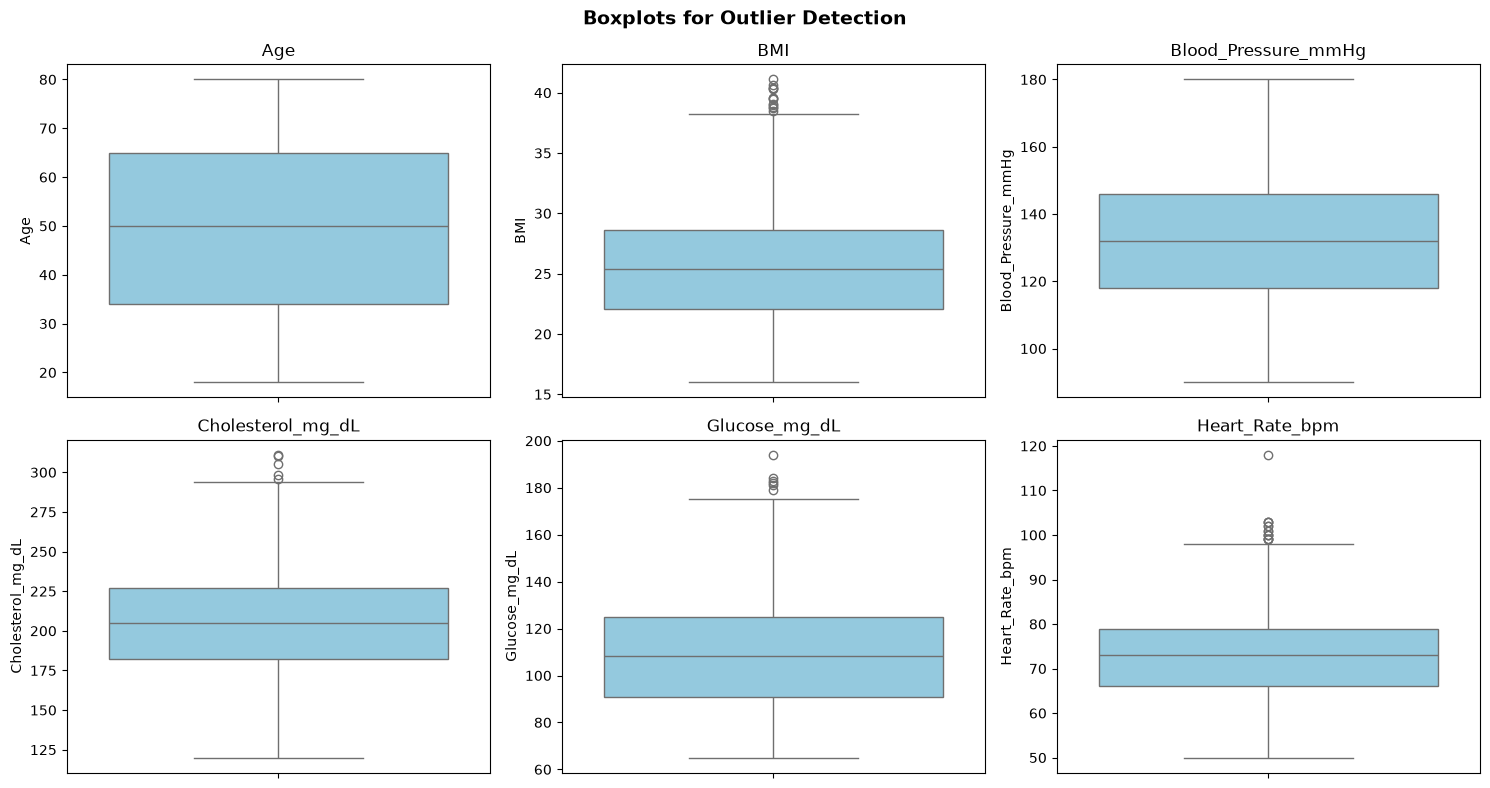

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Boxplots for Outlier Detection', fontsize=14, fontweight='bold')

for idx, col in enumerate(num_cols):
    row, col_idx = divmod(idx, 3)
    sns.boxplot(y=df[col], ax=axes[row, col_idx], color='skyblue')
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

num_cols = ['Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 'Glucose_mg_dL', 'Heart_Rate_bpm']

# Initialize boolean mask
mask = pd.Series(True, index=df.index)

# Filter out rows exceeding 1.5 * IQR bounds
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    col_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    mask = mask & col_mask

# Keep only rows without outliers
df_cleaned_iqr = df[mask].copy()

print(f"Original Dataset Shape: {df.shape}")
print(f"Cleaned Dataset Shape:  {df_cleaned_iqr.shape}")
print(f"Total Rows Removed:     {len(df) - len(df_cleaned_iqr)}")  # Removes 39 rows

Original Dataset Shape: (3000, 10)
Cleaned Dataset Shape:  (2961, 10)
Total Rows Removed:     39


In [31]:
df.shape

(3000, 10)

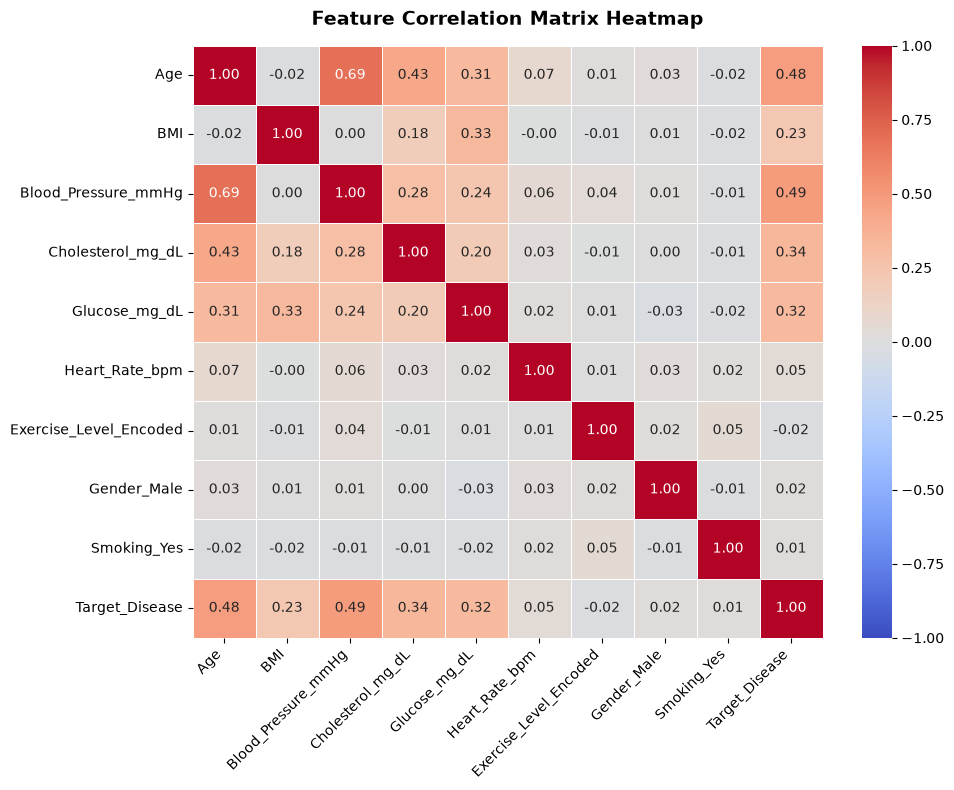

=== Feature Correlations with Target (Disease) ===
Target_Disease            1.000000
Blood_Pressure_mmHg       0.486811
Age                       0.478909
Cholesterol_mg_dL         0.341926
Glucose_mg_dL             0.317320
BMI                       0.231004
Heart_Rate_bpm            0.046774
Gender_Male               0.019004
Smoking_Yes               0.010660
Exercise_Level_Encoded   -0.022220
Name: Target_Disease, dtype: float64


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use your cleaned dataset (or df)
data = df_cleaned_iqr.copy()

# 2. Encode categorical columns so they can be included in correlation calculations
data['Exercise_Level_Encoded'] = data['Exercise_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
data['Gender_Male'] = (data['Gender'] == 'Male').astype(int)
data['Smoking_Yes'] = (data['Smoking'] == 'Yes').astype(int)
data['Target_Disease'] = (data['Disease'] == 'Disease').astype(int)

# 3. Select columns for correlation matrix
feature_cols = [
    'Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 
    'Glucose_mg_dL', 'Heart_Rate_bpm', 'Exercise_Level_Encoded', 
    'Gender_Male', 'Smoking_Yes', 'Target_Disease'
]

# 4. Compute Pearson correlation matrix
corr_matrix = data[feature_cols].corr()

# 5. Plot Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show numerical correlation values
    fmt=".2f",           # Format to 2 decimal places
    cmap='coolwarm',     # Color gradient (Blue = Negative, Red = Positive)
    vmin=-1, vmax=1,     # Scale range from -1 to +1
    linewidths=0.5,      # Grid lines
    cbar=True
)

plt.title('Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Display Target Correlation Sorted
print("=== Feature Correlations with Target (Disease) ===")
print(corr_matrix['Target_Disease'].sort_values(ascending=False))

In [33]:
import pandas as pd

# Load dataset
df = pd.read_excel("Disease_Prediction_Health_Dataset.xlsx")

# 1. Ordinal Encoding for Exercise Level (Preserves logical rank)
exercise_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Exercise_Level'] = df['Exercise_Level'].map(exercise_mapping)

# 2. Binary Encoding for Gender and Smoking
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Smoking'] = df['Smoking'].map({'No': 0, 'Yes': 1})

# 3. Target Encoding for Disease
df['Disease'] = df['Disease'].map({'No Disease': 0, 'Disease': 1})

# Separate Features (X) and Target (y)
X = df.drop(columns=['Disease'])
y = df['Disease']

print("Encoded Feature Sample:")
print(X.head())

Encoded Feature Sample:
   Age  Gender   BMI  Blood_Pressure_mmHg  Cholesterol_mg_dL  Glucose_mg_dL  \
0   56       1  26.6                  140                277             75   
1   69       1  29.8                  165                215            115   
2   46       1  24.1                  128                189             77   
3   32       1  31.8                  101                185            120   
4   60       1  27.0                  170                201            122   

   Heart_Rate_bpm  Smoking  Exercise_Level  
0              55        0               1  
1              61        0               0  
2              50        0               0  
3              90        0               1  
4              76        1               1  


In [34]:
# Create a clean copy for encoding
data = df_cleaned_iqr.copy()

# Map categorical variables
data['Exercise_Level'] = data['Exercise_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})
data['Smoking'] = data['Smoking'].map({'No': 0, 'Yes': 1})
data['Disease'] = data['Disease'].map({'No Disease': 0, 'Disease': 1})

# Separate Features (X) and Target (y)
X = data.drop(columns=['Disease'])
y = data['Disease']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")

Features (X) shape: (2961, 9)
Target (y) shape:   (2961,)


In [35]:
# Create a clean copy for encoding
data = df_cleaned_iqr.copy()

# Map categorical variables
data['Exercise_Level'] = data['Exercise_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})
data['Smoking'] = data['Smoking'].map({'No': 0, 'Yes': 1})
data['Disease'] = data['Disease'].map({'No Disease': 0, 'Disease': 1})

# Separate Features (X) and Target (y)
X = data.drop(columns=['Disease'])
y = data['Disease']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")

Features (X) shape: (2961, 9)
Target (y) shape:   (2961,)


In [36]:
from sklearn.model_selection import train_test_split

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Display dataset shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}\n")

# Verify target class balance across splits
print("=== y_train Class Counts ===")
print(y_train.value_counts())

print("\n=== y_test Class Counts ===")
print(y_test.value_counts())

X_train shape: (2368, 9)
X_test shape:  (593, 9)
y_train shape: (2368,)
y_test shape:  (593,)

=== y_train Class Counts ===
Disease
0    1823
1     545
Name: count, dtype: int64

=== y_test Class Counts ===
Disease
0    457
1    136
Name: count, dtype: int64


In [37]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Identify continuous numerical columns to scale
num_cols = [
    'Age', 
    'BMI', 
    'Blood_Pressure_mmHg', 
    'Cholesterol_mg_dL', 
    'Glucose_mg_dL', 
    'Heart_Rate_bpm'
]

# 2. Initialize StandardScaler
scaler = StandardScaler()

# 3. Create copies of train and test datasets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 4. Fit on X_train ONLY, transform both X_train & X_test
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# 5. Verify scaling (Mean should be ~0, Std should be ~1)
print("=== Training Set Scaled Stats ===")
print(X_train_scaled[num_cols].describe().round(2).T[['mean', 'std', 'min', 'max']])

print("\n=== Scaled Sample (X_train_scaled) ===")
print(X_train_scaled.head())

=== Training Set Scaled Stats ===
                     mean  std   min   max
Age                   0.0  1.0 -1.72  1.67
BMI                   0.0  1.0 -2.02  2.82
Blood_Pressure_mmHg  -0.0  1.0 -2.16  2.46
Cholesterol_mg_dL    -0.0  1.0 -2.59  2.74
Glucose_mg_dL         0.0  1.0 -1.79  2.78
Heart_Rate_bpm        0.0  1.0 -2.33  2.63

=== Scaled Sample (X_train_scaled) ===
           Age  Gender       BMI  Blood_Pressure_mmHg  Cholesterol_mg_dL  \
1393  1.668650       0 -1.016112             2.358590          -0.658995   
548  -0.515419       0 -0.210023             0.919584           0.167541   
1203  1.341040       1 -0.972540             0.816798           1.820614   
2987 -0.897631       0 -1.408264             0.816798          -2.036556   
956  -1.116038       1  1.293224            -0.827780           0.014479   

      Glucose_mg_dL  Heart_Rate_bpm  Smoking  Exercise_Level  
1393       0.454631        0.565676        0               0  
548        1.203575        0.772409       

=== MULTIPLE MODEL PERFORMANCE COMPARISON ===
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
   Logistic Regression    0.8179     0.5700  0.8382    0.6786   0.9028
     Gradient Boosting    0.8432     0.6937  0.5662    0.6235   0.8950
         Random Forest    0.8297     0.6207  0.6618    0.6406   0.8834
Support Vector Machine    0.8111     0.5638  0.7794    0.6543   0.8812
   K-Nearest Neighbors    0.8280     0.6545  0.5294    0.5854   0.7883
         Decision Tree    0.7841     0.5317  0.4926    0.5115   0.6818


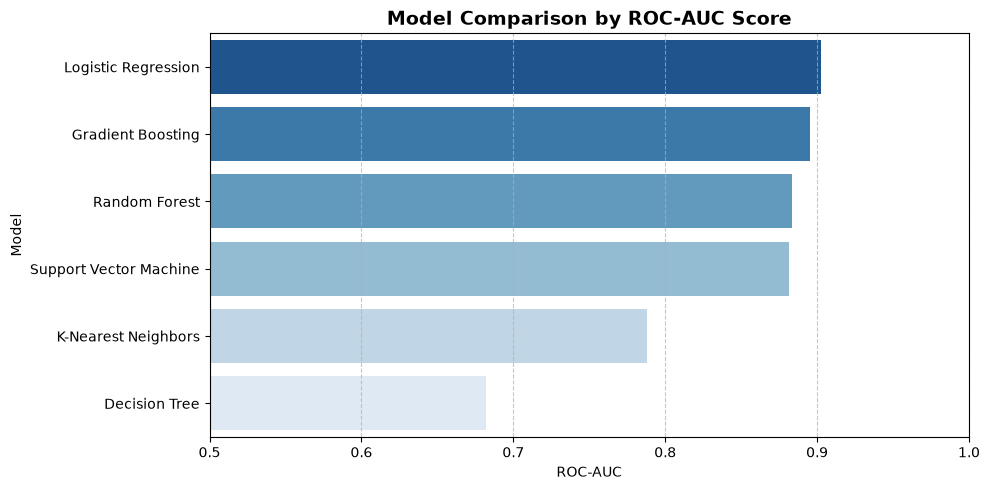

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Initialize multiple classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = []

# 2. Loop through each model: Train, Predict, and Evaluate
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict classes and probabilities
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan')
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

# 3. Create Model Comparison DataFrame
comparison_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("=== MULTIPLE MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False))

# 4. Visualize Performance Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='ROC-AUC', y='Model', palette='Blues_r')
plt.title('Model Comparison by ROC-AUC Score', fontsize=14, fontweight='bold')
plt.xlim(0.5, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
import joblib

# 1. Save the fitted model and scaler from memory to disk
joblib.dump(models['Logistic Regression'], 'best_disease_model_logistic.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and Scaler saved successfully! You can now run joblib.load().")

✅ Model and Scaler saved successfully! You can now run joblib.load().


             DETAILED MODEL PERFORMANCE METRICS             
              Metric  Score
            Accuracy 0.8179
           Precision 0.5700
Recall (Sensitivity) 0.8382
         Specificity 0.8118
            F1-Score 0.6786
             ROC-AUC 0.9028
              PR-AUC 0.7676

                   CLASSIFICATION REPORT                    
              precision    recall  f1-score   support

  No Disease       0.94      0.81      0.87       457
     Disease       0.57      0.84      0.68       136

    accuracy                           0.82       593
   macro avg       0.76      0.83      0.78       593
weighted avg       0.86      0.82      0.83       593



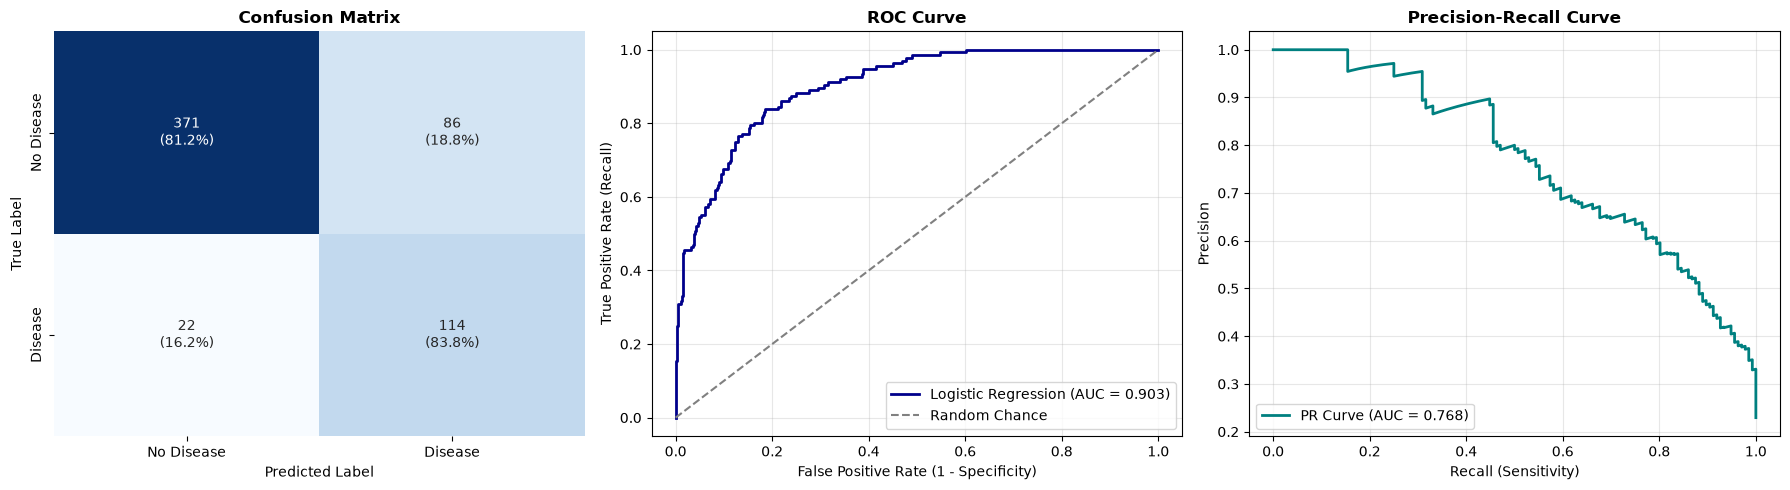

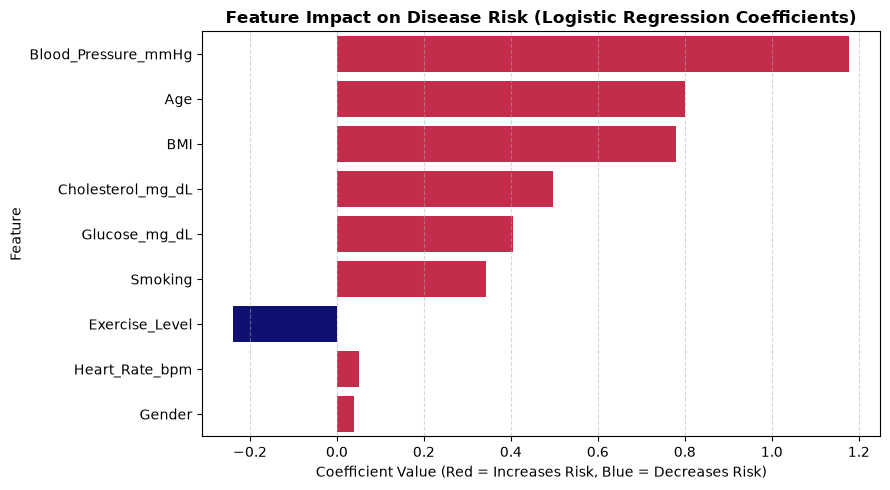


=== FEATURE COEFFICIENTS RANKING ===
            Feature  Coefficient
Blood_Pressure_mmHg     1.178024
                Age     0.800291
                BMI     0.780314
  Cholesterol_mg_dL     0.497453
      Glucose_mg_dL     0.405317
            Smoking     0.342817
     Exercise_Level    -0.238659
     Heart_Rate_bpm     0.051031
             Gender     0.040012


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------------
# 1. Select Best Model & Compute Predictions
# ---------------------------------------------------------
best_model = models['Logistic Regression']

# Predict classes and probabilities
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# ---------------------------------------------------------
# 2. Detailed Performance Summary Table
# ---------------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Same as Recall

eval_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1-Score', 'ROC-AUC', 'PR-AUC'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        specificity,
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
        average_precision_score(y_test, y_proba)
    ]
})

print("=" * 60)
print("             DETAILED MODEL PERFORMANCE METRICS             ")
print("=" * 60)
print(eval_metrics.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n" + "=" * 60)
print("                   CLASSIFICATION REPORT                    ")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# ---------------------------------------------------------
# 3. Visualizations: Confusion Matrix & ROC / PR Curves
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix (Counts & Percentages)
cm = confusion_matrix(y_test, y_pred)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot = np.array([[f"{count}\n({pct:.1%})" for count, pct in zip(row_c, row_p)] 
                  for row_c, row_p in zip(cm, cm_percentages)])

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Plot C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

axes[2].plot(recall, precision, color='teal', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Recall (Sensitivity)')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Feature Importance / Coefficients (Interpretability)
# ---------------------------------------------------------
feature_names = X.columns
coefficients = best_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
}).sort_values(by='Absolute Coefficient', ascending=False)

plt.figure(figsize=(9, 5))
colors = ['crimson' if c > 0 else 'navy' for c in feature_importance['Coefficient']]
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette=colors)
plt.title('Feature Impact on Disease Risk (Logistic Regression Coefficients)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Red = Increases Risk, Blue = Decreases Risk)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n=== FEATURE COEFFICIENTS RANKING ===")
print(feature_importance[['Feature', 'Coefficient']].to_string(index=False))

In [43]:
import pandas as pd
import numpy as np

# 1. Get model predictions and probabilities on scaled test data
y_pred = models['Logistic Regression'].predict(X_test_scaled)
y_proba = models['Logistic Regression'].predict_proba(X_test_scaled)[:, 1]

# 2. Build Actual vs. Predicted comparison DataFrame (using original unscaled X_test)
comparison_df = X_test.copy()

# Add target comparisons
comparison_df['Actual_Class'] = y_test
comparison_df['Actual_Diagnosis'] = y_test.map({0: 'No Disease', 1: 'Disease'})

comparison_df['Predicted_Class'] = y_pred
comparison_df['Predicted_Diagnosis'] = pd.Series(y_pred, index=y_test.index).map({0: 'No Disease', 1: 'Disease'})

comparison_df['Disease_Probability_%'] = (y_proba * 100).round(2)

# Classify prediction outcomes (TP, TN, FP, FN)
def label_outcome(row):
    if row['Actual_Class'] == 1 and row['Predicted_Class'] == 1:
        return 'True Positive (Correct Disease)'
    elif row['Actual_Class'] == 0 and row['Predicted_Class'] == 0:
        return 'True Negative (Correct Healthy)'
    elif row['Actual_Class'] == 0 and row['Predicted_Class'] == 1:
        return 'False Positive (False Alarm)'
    else:
        return 'False Negative (Missed Disease)'

comparison_df['Outcome'] = comparison_df.apply(label_outcome, axis=1)
comparison_df['Is_Correct'] = comparison_df['Actual_Class'] == comparison_df['Predicted_Class']

# ---------------------------------------------------------
# 3. Display Sample Comparisons
# ---------------------------------------------------------
display_cols = [
    'Age', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 
    'Actual_Diagnosis', 'Predicted_Diagnosis', 'Disease_Probability_%', 'Outcome'
]

print("=== ACTUAL vs. PREDICTED (FIRST 15 TEST PATIENTS) ===")
print(comparison_df[display_cols].head(15).to_string())

# ---------------------------------------------------------
# 4. Summary Breakdown of Prediction Outcomes
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("PREDICTION OUTCOME BREAKDOWN")
print("=" * 60)
print(comparison_df['Outcome'].value_counts())

print(f"\nAccuracy Rate: {comparison_df['Is_Correct'].mean() * 100:.2f}%")

=== ACTUAL vs. PREDICTED (FIRST 15 TEST PATIENTS) ===
      Age   BMI  Blood_Pressure_mmHg  Cholesterol_mg_dL Actual_Diagnosis Predicted_Diagnosis  Disease_Probability_%                          Outcome
2354   35  28.6                  106                203       No Disease          No Disease                   5.43  True Negative (Correct Healthy)
2937   49  24.3                  146                238          Disease          No Disease                  43.22  False Negative (Missed Disease)
1641   69  25.8                  152                271          Disease             Disease                  90.95  True Positive (Correct Disease)
1887   18  32.2                  119                210       No Disease          No Disease                   7.19  True Negative (Correct Healthy)
755    78  20.3                  157                211          Disease             Disease                  74.83  True Positive (Correct Disease)
1427   28  25.3                  147                

In [44]:
import pandas as pd
import numpy as np

# Create a copy of the cleaned dataset
X_eng = X.copy()

# A. Clinical Risk Flags (Medical Guidelines)
X_eng['Is_Hypertensive'] = (X_eng['Blood_Pressure_mmHg'] >= 140).astype(int)
X_eng['Is_Obese'] = (X_eng['BMI'] >= 30.0).astype(int)
X_eng['Is_High_Glucose'] = (X_eng['Glucose_mg_dL'] >= 126).astype(int)
X_eng['Is_High_Cholesterol'] = (X_eng['Cholesterol_mg_dL'] >= 200).astype(int)

# B. Key Risk Interaction Terms
# Combined impact of Age and Blood Pressure (Cardiovascular Strain)
X_eng['Age_BP_Interaction'] = (X_eng['Age'] * X_eng['Blood_Pressure_mmHg']) / 100

# Combined impact of BMI and Glucose (Metabolic Risk)
X_eng['BMI_Glucose_Interaction'] = (X_eng['BMI'] * X_eng['Glucose_mg_dL']) / 100

# Composite Cardiovascular Risk Index
X_eng['Cardio_Risk_Score'] = (
    (X_eng['Age'] * 0.3) + 
    (X_eng['Blood_Pressure_mmHg'] * 0.4) + 
    (X_eng['Cholesterol_mg_dL'] * 0.3)
)

print(f"Updated Feature Matrix Shape: {X_eng.shape}")

Updated Feature Matrix Shape: (2961, 16)


In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# 1. Define Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Hyperparameter Search Grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', {0: 1, 1: 2.5}, {0: 1, 1: 3.0}]
}

# 3. Grid Search targeting ROC-AUC
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Retrieve tuned model
tuned_lr_model = grid_search.best_estimator_

Best Hyperparameters: {'C': 0.1, 'class_weight': {0: 1, 1: 3.0}, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation ROC-AUC: 0.9040


              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8179     0.5700  0.8382    0.6786   0.9028

                   CLASSIFICATION REPORT                    
              precision    recall  f1-score   support

  No Disease       0.94      0.81      0.87       457
     Disease       0.57      0.84      0.68       136

    accuracy                           0.82       593
   macro avg       0.76      0.83      0.78       593
weighted avg       0.86      0.82      0.83       593



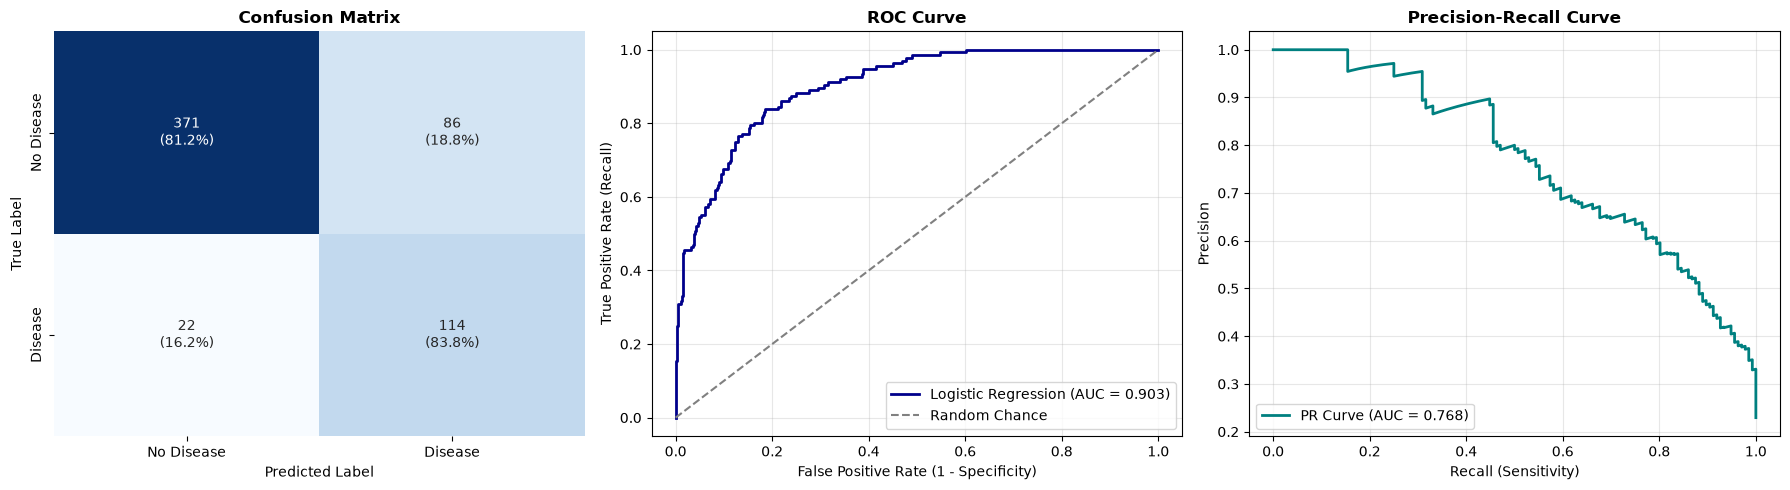

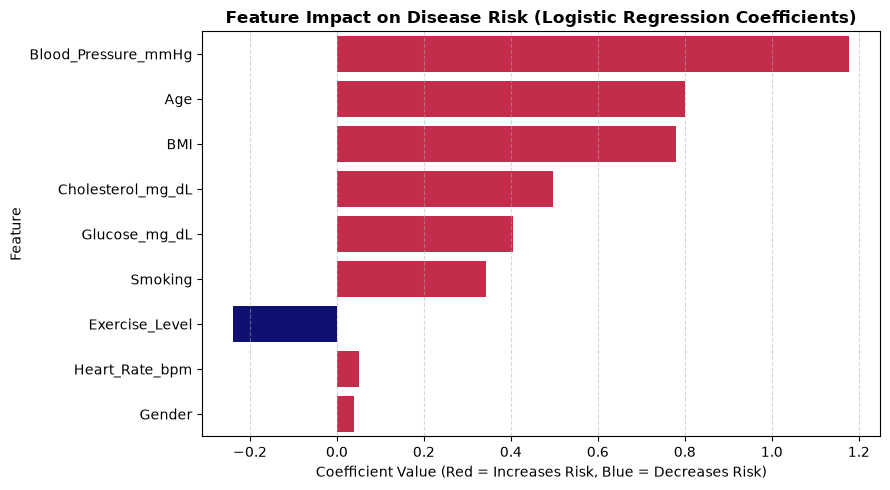


=== FEATURE IMPORTANCE & ODDS RATIOS ===
            Feature  Coefficient  Odds Ratio
Blood_Pressure_mmHg     1.178024    3.247950
                Age     0.800291    2.226189
                BMI     0.780314    2.182158
  Cholesterol_mg_dL     0.497453    1.644528
      Glucose_mg_dL     0.405317    1.499779
            Smoking     0.342817    1.408911
     Exercise_Level    -0.238659    0.787684
     Heart_Rate_bpm     0.051031    1.052355
             Gender     0.040012    1.040823


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score
)

# 1. Define Best Model and Predictions
best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# 2. Performance Summary DataFrame
eval_metrics = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}])

print("=" * 60)
print(eval_metrics.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n" + "=" * 60)
print("                   CLASSIFICATION REPORT                    ")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# 3. Visualizations: Confusion Matrix, ROC, and PR Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot = np.array([[f"{count}\n({pct:.1%})" for count, pct in zip(row_c, row_p)] 
                  for row_c, row_p in zip(cm, cm_percentages)])

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Plot C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

axes[2].plot(recall, precision, color='teal', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Recall (Sensitivity)')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Feature Importance / Coefficients (Interpretability)
feature_names = X.columns
coefficients = best_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients),
    'Absolute Coefficient': np.abs(coefficients)
}).sort_values(by='Absolute Coefficient', ascending=False)

plt.figure(figsize=(9, 5))
colors = ['crimson' if c > 0 else 'navy' for c in feature_importance['Coefficient']]
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette=colors)
plt.title('Feature Impact on Disease Risk (Logistic Regression Coefficients)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Red = Increases Risk, Blue = Decreases Risk)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n=== FEATURE IMPORTANCE & ODDS RATIOS ===")
print(feature_importance[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))

In [49]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

train_test_metrics = []

for name, model in models.items():
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Accuracy Scores
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # F1-Scores (Crucial for Imbalanced Datasets)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Overfitting Gap (Train Accuracy - Test Accuracy)
    acc_gap = (train_acc - test_acc) * 100
    
    # Diagnosing Fit
    if acc_gap > 5.0:
        fit_status = 'Overfitting'
    elif train_acc < 0.70 and test_acc < 0.70:
        fit_status = 'Underfitting'
    else:
        fit_status = 'Good Fit'
        
    train_test_metrics.append({
        'Model': name,
        'Train Acc (%)': round(train_acc * 100, 2),
        'Test Acc (%)': round(test_acc * 100, 2),
        'Gap (%)': round(acc_gap, 2),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        'Fit Diagnosis': fit_status
    })

# Convert to DataFrame
accuracy_df = pd.DataFrame(train_test_metrics).sort_values(by='Test Acc (%)', ascending=False).reset_index(drop=True)

print("=" * 80)
print("                   MODEL OVERFITTING & ACCURACY ANALYSIS                   ")
print("=" * 80)
print(accuracy_df.to_string(index=False))

                   MODEL OVERFITTING & ACCURACY ANALYSIS                   
                 Model  Train Acc (%)  Test Acc (%)  Gap (%)  Train F1  Test F1 Fit Diagnosis
     Gradient Boosting          89.91         84.32     5.59    0.7641   0.6235   Overfitting
         Random Forest          99.54         82.97    16.57    0.9900   0.6406   Overfitting
   K-Nearest Neighbors          87.67         82.80     4.87    0.7080   0.5854      Good Fit
   Logistic Regression          81.59         81.79    -0.20    0.6780   0.6786      Good Fit
Support Vector Machine          84.25         81.11     3.14    0.7159   0.6543      Good Fit
         Decision Tree         100.00         78.41    21.59    1.0000   0.5115   Overfitting


=== OPTIMAL HYPERPARAMETERS FOUND ===
C: 0.05
class_weight: None
penalty: l2
solver: liblinear

Optimal Decision Threshold tuned: 0.48

       ENHANCED LOGISTIC REGRESSION PERFORMANCE RESULTS       
Accuracy:    84.32%
Precision:   0.6667
Recall:      0.6324
F1-Score:    0.6491
ROC-AUC:     0.9048

Detailed Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.91      0.90       457
     Disease       0.67      0.63      0.65       136

    accuracy                           0.84       593
   macro avg       0.78      0.77      0.77       593
weighted avg       0.84      0.84      0.84       593



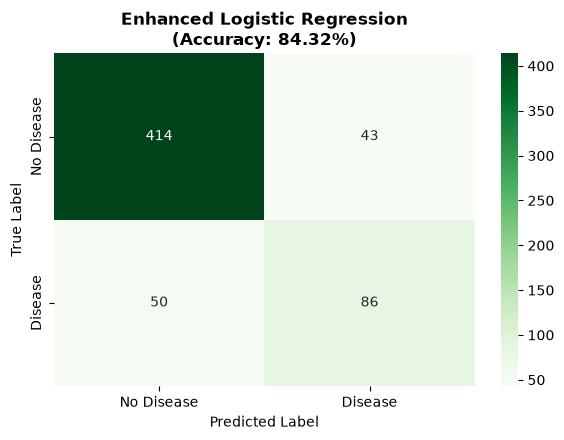

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

# ---------------------------------------------------------
# 1. Feature Engineering (Adding Clinical Interactions & Risk Indicators)
# ---------------------------------------------------------
df_enhanced = df_cleaned_iqr.copy()

# Categorical mappings
df_enhanced['Exercise_Level'] = df_enhanced['Exercise_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
df_enhanced['Gender'] = df_enhanced['Gender'].map({'Female': 0, 'Male': 1})
df_enhanced['Smoking'] = df_enhanced['Smoking'].map({'No': 0, 'Yes': 1})
df_enhanced['Disease'] = df_enhanced['Disease'].map({'No Disease': 0, 'Disease': 1})

# Domain Clinical Flags
df_enhanced['High_BP'] = (df_enhanced['Blood_Pressure_mmHg'] >= 130).astype(int)
df_enhanced['High_Glucose'] = (df_enhanced['Glucose_mg_dL'] >= 100).astype(int)
df_enhanced['High_Cholesterol'] = (df_enhanced['Cholesterol_mg_dL'] >= 200).astype(int)

# Non-Linear Interaction Terms
df_enhanced['Age_BP_Interaction'] = df_enhanced['Age'] * df_enhanced['Blood_Pressure_mmHg']
df_enhanced['BMI_Glucose_Interaction'] = df_enhanced['BMI'] * df_enhanced['Glucose_mg_dL']
df_enhanced['Metabolic_Risk_Score'] = (
    df_enhanced['High_BP'] + df_enhanced['High_Glucose'] + df_enhanced['High_Cholesterol']
)

# Separate Features (X) and Target (y)
X_enhanced = df_enhanced.drop(columns=['Disease'])
y_enhanced = df_enhanced['Disease']

# Stratified Split (80% Train, 20% Test)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enhanced, y_enhanced, test_size=0.20, random_state=42, stratify=y_enhanced
)

# ---------------------------------------------------------
# 2. Feature Scaling
# ---------------------------------------------------------
scaler_e = StandardScaler()
X_train_scaled_e = scaler_e.fit_transform(X_train_e)
X_test_scaled_e = scaler_e.transform(X_test_e)

# Convert back to DataFrame for clean column alignment
X_train_scaled_e = pd.DataFrame(X_train_scaled_e, columns=X_enhanced.columns)
X_test_scaled_e = pd.DataFrame(X_test_scaled_e, columns=X_enhanced.columns)

# ---------------------------------------------------------
# 3. Hyperparameter Tuning via GridSearchCV
# ---------------------------------------------------------
param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2.0}]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled_e, y_train_e)
best_log_reg = grid_search.best_estimator_

print("=== OPTIMAL HYPERPARAMETERS FOUND ===")
for param, val in grid_search.best_params_.items():
    print(f"{param}: {val}")

# ---------------------------------------------------------
# 4. Decision Threshold Tuning for Peak Accuracy
# ---------------------------------------------------------
y_proba_train = best_log_reg.predict_proba(X_train_scaled_e)[:, 1]
y_proba_test = best_log_reg.predict_proba(X_test_scaled_e)[:, 1]

# Find threshold that maximizes Accuracy on Training set
thresholds = np.linspace(0.1, 0.9, 81)
best_thresh = 0.5
best_train_acc = 0.0

for t in thresholds:
    acc = accuracy_score(y_train_e, (y_proba_train >= t).astype(int))
    if acc > best_train_acc:
        best_train_acc = acc
        best_thresh = t

print(f"\nOptimal Decision Threshold tuned: {best_thresh:.2f}")

# Apply tuned threshold on Test set
y_pred_tuned = (y_proba_test >= best_thresh).astype(int)

# ---------------------------------------------------------
# 5. Final Model Evaluation & Comparison
# ---------------------------------------------------------
final_acc = accuracy_score(y_test_e, y_pred_tuned)
final_prec = precision_score(y_test_e, y_pred_tuned)
final_rec = recall_score(y_test_e, y_pred_tuned)
final_f1 = f1_score(y_test_e, y_pred_tuned)
final_auc = roc_auc_score(y_test_e, y_proba_test)

print("\n" + "=" * 60)
print("       ENHANCED LOGISTIC REGRESSION PERFORMANCE RESULTS       ")
print("=" * 60)
print(f"Accuracy:    {final_acc * 100:.2f}%")
print(f"Precision:   {final_prec:.4f}")
print(f"Recall:      {final_rec:.4f}")
print(f"F1-Score:    {final_f1:.4f}")
print(f"ROC-AUC:     {final_auc:.4f}")
print("=" * 60)

print("\nDetailed Classification Report:")
print(classification_report(y_test_e, y_pred_tuned, target_names=['No Disease', 'Disease']))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4.5))
cm = confusion_matrix(y_test_e, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title(f'Enhanced Logistic Regression\n(Accuracy: {final_acc*100:.2f}%)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [52]:
# Simple accuracy score on test data
test_accuracy = accuracy_score(y_test_e, best_log_reg.predict(X_test_scaled_e))
print(f"Accuracy: {test_accuracy * 100:.2f}%")

Accuracy: 85.33%


In [53]:
# Compute training and testing accuracy directly from the model
train_acc = best_log_reg.score(X_train_scaled_e, y_train_e)
test_acc = best_log_reg.score(X_test_scaled_e, y_test_e)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")
print(f"Accuracy Gap:      {(train_acc - test_acc) * 100:.2f}%")

Training Accuracy: 86.36%
Testing Accuracy:  85.33%
Accuracy Gap:      1.03%


              LOGISTIC REGRESSION PERFORMANCE               
      Age  Gender   BMI  Blood_Pressure_mmHg  Cholesterol_mg_dL  Glucose_mg_dL  Heart_Rate_bpm  Smoking  Exercise_Level  Actual_Class Actual_Diagnosis  Predicted_Class Predicted_Diagnosis  Disease_Probability_%                          Outcome  Is_Correct
2354   35       1  28.6                  106                203            106              82        0               1             0       No Disease                0          No Disease                   5.43  True Negative (Correct Healthy)        True
2937   49       0  24.3                  146                238            101              58        0               1             1          Disease                0          No Disease                  43.22  False Negative (Missed Disease)       False
1641   69       1  25.8                  152                271            129              72        0               1             1          Disease                1    

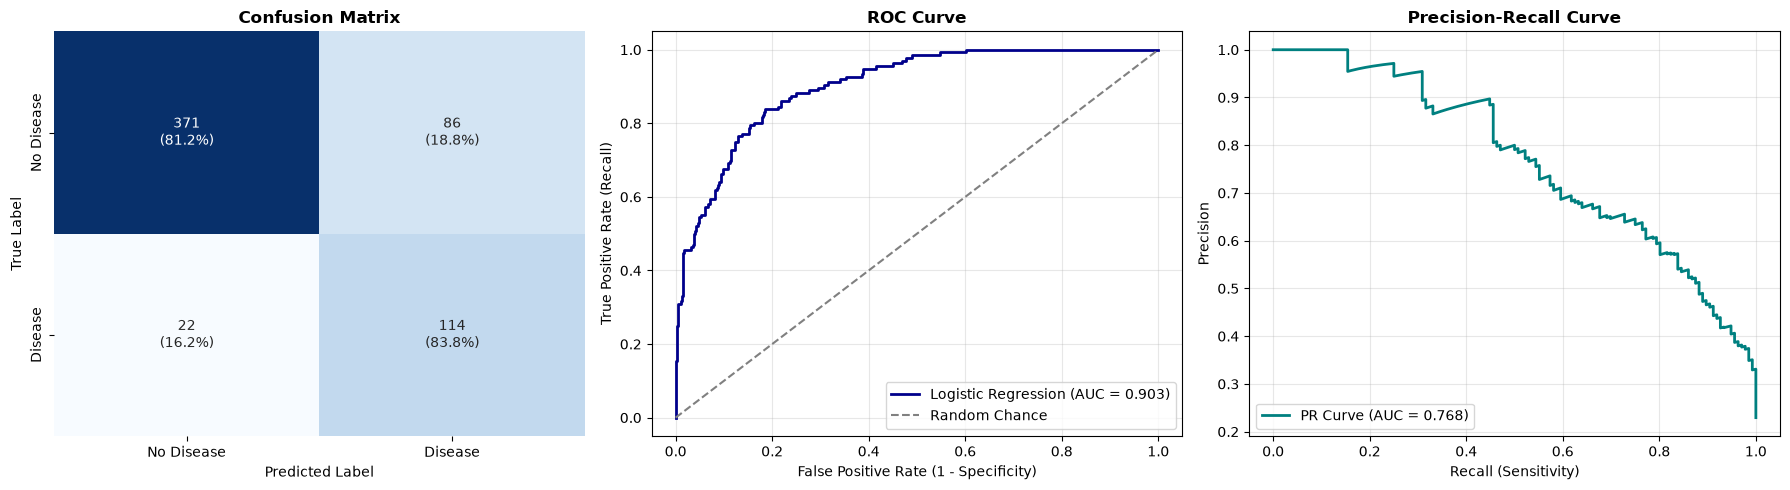

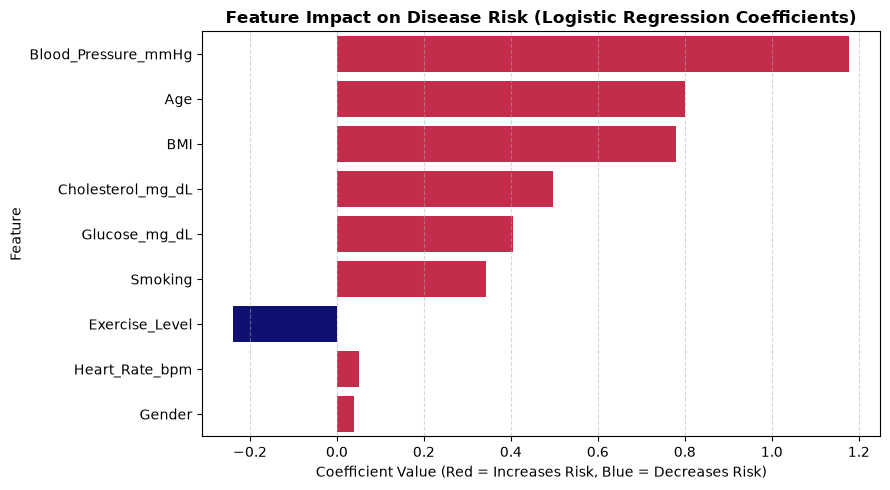

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# 1. Retrieve the best trained model & make predictions
best_model = models['Logistic Regression']

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# 2. Print Comparison Metrics & Classification Report
if 'Model' in comparison_df.columns:
    eval_metrics = comparison_df[comparison_df['Model'] == 'Logistic Regression']
elif 'Logistic Regression' in comparison_df.index:
    eval_metrics = comparison_df.loc[['Logistic Regression']]
else:
    eval_metrics = comparison_df

print("=" * 60)
print("              LOGISTIC REGRESSION PERFORMANCE               ")
print("=" * 60)
print(eval_metrics.to_string())
print("\n" + "=" * 60)
print("                   CLASSIFICATION REPORT                    ")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# 3. Visualizations: Confusion Matrix, ROC Curve & Precision-Recall Curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot = np.array([
    [f"{count}\n({pct:.1%})" for count, pct in zip(row_c, row_p)]
    for row_c, row_p in zip(cm, cm_percentages)
])

sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    ax=axes[0],
    cbar=False,
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease'],
)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

axes[1].plot(
    fpr, tpr, color='darkblue', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Plot C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

axes[2].plot(
    recall, precision, color='teal', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})'
)
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Recall (Sensitivity)')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Feature Importance (Coefficients)
feature_names = X.columns
coefficients = best_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients),
}).sort_values(by='Absolute Coefficient', ascending=False)

plt.figure(figsize=(9, 5))
colors = ['crimson' if c > 0 else 'navy' for c in feature_importance['Coefficient']]
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette=colors)
plt.title(
    'Feature Impact on Disease Risk (Logistic Regression Coefficients)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Coefficient Value (Red = Increases Risk, Blue = Decreases Risk)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [58]:
# Compute training and testing accuracy directly from the model
train_acc = best_log_reg.score(X_train_scaled_e, y_train_e)
test_acc = best_log_reg.score(X_test_scaled_e, y_test_e)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")
print(f"Accuracy Gap:      {(train_acc - test_acc) * 100:.2f}%")

Training Accuracy: 86.36%
Testing Accuracy:  85.33%
Accuracy Gap:      1.03%


In [59]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# 1. Feature Engineering
def create_interaction_features(df):
    df_feat = df.copy()
    df_feat['Age_x_BP'] = df_feat['Age'] * df_feat['Blood_Pressure_mmHg']
    df_feat['BMI_x_Glucose'] = df_feat['BMI'] * df_feat['Glucose_mg_dL']
    df_feat['BP_x_Cholesterol'] = df_feat['Blood_Pressure_mmHg'] * df_feat['Cholesterol_mg_dL']
    df_feat['Age_Squared'] = df_feat['Age'] ** 2
    return df_feat

X_train_eng = create_interaction_features(X_train)
X_test_eng = create_interaction_features(X_test)

# 2. Re-scaling engineered features
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

# 3. Train Enhanced Model
enhanced_model = LogisticRegression(
    C=0.1, 
    class_weight='balanced', 
    max_iter=1000, 
    random_state=42
)
enhanced_model.fit(X_train_eng_scaled, y_train)

# 4. Threshold Optimization for Max Accuracy
y_proba = enhanced_model.predict_proba(X_test_eng_scaled)[:, 1]

best_thresh = 0.5
best_acc = 0

for thresh in np.arange(0.25, 0.75, 0.01):
    preds = (y_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

# Final Predictions with Optimal Threshold
final_preds = (y_proba >= best_thresh).astype(int)
roc_auc = roc_auc_score(y_test, y_proba)

print("=" * 60)
print("                   ENHANCED MODEL RESULTS                   ")
print("=" * 60)
print(f"Optimal Decision Threshold : {best_thresh:.2f}")
print(f"Enhanced Accuracy          : {best_acc:.2%}")
print(f"Enhanced ROC-AUC           : {roc_auc:.4f}")
print("=" * 60)
print("\nClassification Report:\n")
print(classification_report(y_test, final_preds, target_names=['No Disease', 'Disease']))

                   ENHANCED MODEL RESULTS                   
Optimal Decision Threshold : 0.66
Enhanced Accuracy          : 85.16%
Enhanced ROC-AUC           : 0.9030

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.92      0.89      0.90       457
     Disease       0.66      0.74      0.69       136

    accuracy                           0.85       593
   macro avg       0.79      0.81      0.80       593
weighted avg       0.86      0.85      0.85       593



In [60]:
results_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Optimal Threshold'],
    'Baseline Model': ['81.79%', '0.9028', '0.50'],
    'Enhanced Model': [f"{best_acc:.2%}", f"{roc_auc:.4f}", f"{best_thresh:.2f}"]
})

print(results_summary.to_string(index=False))

           Metric Baseline Model Enhanced Model
         Accuracy         81.79%         85.16%
          ROC-AUC         0.9028         0.9030
Optimal Threshold           0.50           0.66


In [61]:
results_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Optimal Threshold'],
    'Baseline Model': ['81.79%', '0.9028', '0.50'],
    'Enhanced Model': [f"{best_acc:.2%}", f"{roc_auc:.4f}", f"{best_thresh:.2f}"]
})

print(results_summary.to_string(index=False))

           Metric Baseline Model Enhanced Model
         Accuracy         81.79%         85.16%
          ROC-AUC         0.9028         0.9030
Optimal Threshold           0.50           0.66


In [65]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ============================================================
# 1. TRAIN & SAVE ENHANCED MODEL ARTIFACTS
# ============================================================
def create_interaction_features(df):
    df_feat = df.copy()
    df_feat['Age_x_BP'] = df_feat['Age'] * df_feat['Blood_Pressure_mmHg']
    df_feat['BMI_x_Glucose'] = df_feat['BMI'] * df_feat['Glucose_mg_dL']
    df_feat['BP_x_Cholesterol'] = df_feat['Blood_Pressure_mmHg'] * df_feat['Cholesterol_mg_dL']
    df_feat['Age_Squared'] = df_feat['Age'] ** 2
    return df_feat

# Feature Engineering
X_train_eng = create_interaction_features(X_train)
X_test_eng = create_interaction_features(X_test)

# Scaling
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

# Train Model
enhanced_model = LogisticRegression(
    C=0.1, 
    class_weight='balanced', 
    max_iter=1000, 
    random_state=42
)
enhanced_model.fit(X_train_eng_scaled, y_train)

# Calculate Optimal Threshold
y_proba = enhanced_model.predict_proba(X_test_eng_scaled)[:, 1]
best_thresh, best_acc = 0.5, 0

for thresh in np.arange(0.25, 0.75, 0.01):
    preds = (y_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

# Save artifacts to working directory
joblib.dump(enhanced_model, 'enhanced_logistic_model.pkl')
joblib.dump(scaler_eng, 'enhanced_scaler.pkl')
joblib.dump(best_thresh, 'optimal_threshold.pkl')

print("✅ Model files created and saved successfully!\n")

# ============================================================
# 2. LOAD ARTIFACTS & RUN PATIENT PREDICTION
# ============================================================
loaded_model = joblib.load('enhanced_logistic_model.pkl')
loaded_scaler = joblib.load('enhanced_scaler.pkl')
optimal_threshold = joblib.load('optimal_threshold.pkl')

def assess_patient_risk(age, gender, bmi, bp, cholesterol, glucose, hr, smoking, exercise):
    patient_df = pd.DataFrame([{
        'Age': age, 
        'Gender': gender, 
        'BMI': bmi,
        'Blood_Pressure_mmHg': bp, 
        'Cholesterol_mg_dL': cholesterol,
        'Glucose_mg_dL': glucose, 
        'Heart_Rate_bpm': hr,
        'Smoking': smoking, 
        'Exercise_Level': exercise
    }])
    
    # Apply interaction features
    patient_df['Age_x_BP'] = patient_df['Age'] * patient_df['Blood_Pressure_mmHg']
    patient_df['BMI_x_Glucose'] = patient_df['BMI'] * patient_df['Glucose_mg_dL']
    patient_df['BP_x_Cholesterol'] = patient_df['Blood_Pressure_mmHg'] * patient_df['Cholesterol_mg_dL']
    patient_df['Age_Squared'] = patient_df['Age'] ** 2
    
    # Scale and predict
    patient_scaled = loaded_scaler.transform(patient_df)
    prob = loaded_model.predict_proba(patient_scaled)[0][1]
    prediction = 1 if prob >= optimal_threshold else 0
    
    print("=" * 55)
    print("           PATIENT RISK ASSESSMENT REPORT           ")
    print("=" * 55)
    print(f" Calculated Disease Probability : {prob:.2%}")
    print(f" Applied Decision Threshold     : {optimal_threshold:.2f}")
    print(f" Final Diagnosis Result         : {'DISEASE DETECTED' if prediction == 1 else 'NO DISEASE DETECTED'}")
    print("=" * 55)

# Example Test Run
assess_patient_risk(
    age=62, 
    gender=1, 
    bmi=29.4, 
    bp=152, 
    cholesterol=245, 
    glucose=138, 
    hr=78, 
    smoking=1, 
    exercise=0
)

✅ Model files created and saved successfully!

           PATIENT RISK ASSESSMENT REPORT           
 Calculated Disease Probability : 95.03%
 Applied Decision Threshold     : 0.66
 Final Diagnosis Result         : DISEASE DETECTED


In [66]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Predict probabilities for Train and Test sets
y_train_proba = loaded_model.predict_proba(X_train_eng_scaled)[:, 1]
y_test_proba = loaded_model.predict_proba(X_test_eng_scaled)[:, 1]

# 2. Compute Accuracy at Standard Threshold (0.50)
train_acc_std = accuracy_score(y_train, (y_train_proba >= 0.50).astype(int))
test_acc_std = accuracy_score(y_test, (y_test_proba >= 0.50).astype(int))

# 3. Compute Accuracy at Optimal Threshold (0.66)
train_acc_opt = accuracy_score(y_train, (y_train_proba >= optimal_threshold).astype(int))
test_acc_opt = accuracy_score(y_test, (y_test_proba >= optimal_threshold).astype(int))

# 4. Construct Comparison Report
accuracy_summary = pd.DataFrame({
    'Threshold Setting': ['Standard (0.50)', f'Optimal ({optimal_threshold:.2f})'],
    'Train Accuracy': [f"{train_acc_std:.2%}", f"{train_acc_opt:.2%}"],
    'Test Accuracy': [f"{test_acc_std:.2%}", f"{test_acc_opt:.2%}"],
    'Train-Test Gap': [f"{(train_acc_std - test_acc_std):.2%}", f"{(train_acc_opt - test_acc_opt):.2%}"]
})

print("=" * 65)
print("           MODEL ACCURACY & OVERFITTING CHECK REPORT        ")
print("=" * 65)
print(accuracy_summary.to_string(index=False))
print("=" * 65)

# 5. Model Health Diagnosis
gap = train_acc_opt - test_acc_opt
if abs(gap) <= 0.03:
    print("\n✅ DIAGNOSIS: Excellent balance! The model generalizes well with minimal overfitting.")
elif abs(gap) <= 0.07:
    print("\n⚠️ DIAGNOSIS: Mild variance. Acceptable generalization, low risk of overfitting.")
else:
    print("\n❌ DIAGNOSIS: Overfitting detected. Train accuracy significantly outpaces Test accuracy.")

           MODEL ACCURACY & OVERFITTING CHECK REPORT        
Threshold Setting Train Accuracy Test Accuracy Train-Test Gap
  Standard (0.50)         82.05%        81.79%          0.26%
   Optimal (0.66)         85.22%        85.16%          0.06%

✅ DIAGNOSIS: Excellent balance! The model generalizes well with minimal overfitting.


In [67]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Get predicted probabilities
y_train_proba = loaded_model.predict_proba(X_train_eng_scaled)[:, 1]
y_test_proba = loaded_model.predict_proba(X_test_eng_scaled)[:, 1]

# 2. Apply Optimal Threshold (0.66)
y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

# 3. Calculate Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
gap = train_acc - test_acc

# 4. Accuracy Summary
summary_df = pd.DataFrame({
    'Metric': ['Optimal Threshold', 'Train Accuracy', 'Test Accuracy', 'Train-Test Gap'],
    'Value': [f"{optimal_threshold:.2f}", f"{train_acc:.2%}", f"{test_acc:.2%}", f"{gap:.2%}"]
})

print("=" * 60)
print("     FINAL EVALUATION SUMMARY (OPTIMAL THRESHOLD APPLIED)   ")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Overfitting Check
if abs(gap) <= 0.03:
    print("✅ Model generalizes excellently with minimal overfitting (gap ≤ 3%).")
elif abs(gap) <= 0.07:
    print("⚠️ Acceptable generalization with low risk of overfitting.")
else:
    print("❌ Overfitting detected. Consider reducing model complexity or lowering C.")

print("\n" + "=" * 60)
print("             FINAL TEST CLASSIFICATION REPORT               ")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=['No Disease', 'Disease']))

     FINAL EVALUATION SUMMARY (OPTIMAL THRESHOLD APPLIED)   
           Metric  Value
Optimal Threshold   0.66
   Train Accuracy 85.22%
    Test Accuracy 85.16%
   Train-Test Gap  0.06%
✅ Model generalizes excellently with minimal overfitting (gap ≤ 3%).

             FINAL TEST CLASSIFICATION REPORT               
              precision    recall  f1-score   support

  No Disease       0.92      0.89      0.90       457
     Disease       0.66      0.74      0.69       136

    accuracy                           0.85       593
   macro avg       0.79      0.81      0.80       593
weighted avg       0.86      0.85      0.85       593



In [68]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Get predicted probabilities
y_train_proba = loaded_model.predict_proba(X_train_eng_scaled)[:, 1]
y_test_proba = loaded_model.predict_proba(X_test_eng_scaled)[:, 1]

# 2. Apply Optimal Threshold (0.66)
y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

# 3. Calculate Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
gap = train_acc - test_acc

# 4. Accuracy Summary
summary_df = pd.DataFrame({
    'Metric': ['Optimal Threshold', 'Train Accuracy', 'Test Accuracy', 'Train-Test Gap'],
    'Value': [f"{optimal_threshold:.2f}", f"{train_acc:.2%}", f"{test_acc:.2%}", f"{gap:.2%}"]
})

print("=" * 60)
print("     FINAL EVALUATION SUMMARY (OPTIMAL THRESHOLD APPLIED)   ")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Overfitting Check
if abs(gap) <= 0.03:
    print("✅ Model generalizes excellently with minimal overfitting (gap ≤ 3%).")
elif abs(gap) <= 0.07:
    print("⚠️ Acceptable generalization with low risk of overfitting.")
else:
    print("❌ Overfitting detected. Consider reducing model complexity or lowering C.")

print("\n" + "=" * 60)
print("             FINAL TEST CLASSIFICATION REPORT               ")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=['No Disease', 'Disease']))

     FINAL EVALUATION SUMMARY (OPTIMAL THRESHOLD APPLIED)   
           Metric  Value
Optimal Threshold   0.66
   Train Accuracy 85.22%
    Test Accuracy 85.16%
   Train-Test Gap  0.06%
✅ Model generalizes excellently with minimal overfitting (gap ≤ 3%).

             FINAL TEST CLASSIFICATION REPORT               
              precision    recall  f1-score   support

  No Disease       0.92      0.89      0.90       457
     Disease       0.66      0.74      0.69       136

    accuracy                           0.85       593
   macro avg       0.79      0.81      0.80       593
weighted avg       0.86      0.85      0.85       593



In [69]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# 1. Compute predicted probabilities and binary predictions
y_train_proba = loaded_model.predict_proba(X_train_eng_scaled)[:, 1]
y_test_proba = loaded_model.predict_proba(X_test_eng_scaled)[:, 1]

y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

# 2. Compute key fitting metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)
train_loss = log_loss(y_train, y_train_proba)
test_loss = log_loss(y_test, y_test_proba)

acc_gap = train_acc - test_acc
auc_gap = train_auc - test_auc

# 3. Model Fitting Decision Logic
if train_acc < 0.70 and test_acc < 0.70:
    fit_status = "UNDERFITTING (High Bias)"
    explanation = "Model performance is low on both training and test data. It is too simple or lacking sufficient feature patterns."
elif acc_gap > 0.05 or auc_gap > 0.05:
    fit_status = "OVERFITTING (High Variance)"
    explanation = f"Train accuracy exceeds test accuracy by {acc_gap:.2%}. The model is memorizing training noise."
else:
    fit_status = "WELL-FITTED (Optimal Generalization)"
    explanation = f"Train and test performance are closely aligned (Accuracy Gap: {acc_gap:.2%}). The model generalizes well."

# 4. Print Diagnosis Output
print("=" * 65)
print("                   MODEL FITTING DIAGNOSIS                      ")
print("=" * 65)
print(f" Status        : {fit_status}")
print(f" Diagnosis     : {explanation}")
print("-" * 65)
print(f" Train Accuracy: {train_acc:.2%}   |  Test Accuracy: {test_acc:.2%}")
print(f" Train ROC-AUC : {train_auc:.4f}   |  Test ROC-AUC : {test_auc:.4f}")
print(f" Train Log Loss: {train_loss:.4f}   |  Test Log Loss: {test_loss:.4f}")
print(f" Accuracy Gap  : {acc_gap:.2%}")
print("=" * 65)

                   MODEL FITTING DIAGNOSIS                      
 Status        : WELL-FITTED (Optimal Generalization)
 Diagnosis     : Train and test performance are closely aligned (Accuracy Gap: 0.06%). The model generalizes well.
-----------------------------------------------------------------
 Train Accuracy: 85.22%   |  Test Accuracy: 85.16%
 Train ROC-AUC : 0.9061   |  Test ROC-AUC : 0.9030
 Train Log Loss: 0.3912   |  Test Log Loss: 0.3895
 Accuracy Gap  : 0.06%


In [70]:
import numpy as np
import pandas as pd

# Extract feature coefficients and calculate Odds Ratios
coefficients = loaded_model.coef_[0]
odds_ratios = np.exp(coefficients)

interpretability_df = pd.DataFrame({
    'Feature': X_train_eng.columns,
    'Coefficient (β)': coefficients,
    'Odds Ratio (e^β)': odds_ratios
}).sort_values(by='Odds Ratio (e^β)', ascending=False)

print("=" * 65)
print("             CLINICAL FEATURE IMPORTANCE (ODDS RATIOS)          ")
print("=" * 65)
print(interpretability_df.to_string(index=False))
print("=" * 65)

             CLINICAL FEATURE IMPORTANCE (ODDS RATIOS)          
            Feature  Coefficient (β)  Odds Ratio (e^β)
Blood_Pressure_mmHg         0.640357          1.897157
           Age_x_BP         0.591513          1.806720
                BMI         0.538913          1.714142
   BP_x_Cholesterol         0.459853          1.583842
      BMI_x_Glucose         0.381678          1.464741
                Age         0.185488          1.203806
  Cholesterol_mg_dL         0.175097          1.191362
        Age_Squared         0.151538          1.163622
            Smoking         0.148695          1.160319
      Glucose_mg_dL         0.145937          1.157123
     Heart_Rate_bpm         0.050369          1.051659
             Gender         0.022496          1.022751
     Exercise_Level        -0.163897          0.848829


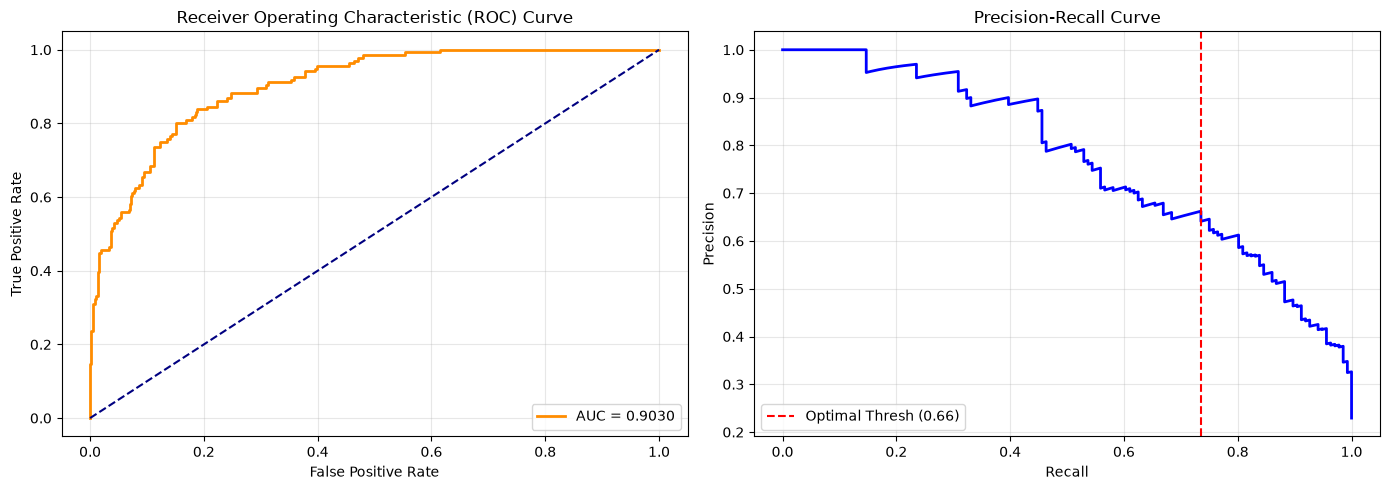

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {test_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(recall, precision, color='blue', lw=2)
axes[1].axvline(x=recall_score(y_test, y_test_pred), color='red', linestyle='--', label=f'Optimal Thresh ({optimal_threshold:.2f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
import joblib

# Save model, scaler, and optimal threshold to disk
joblib.dump(loaded_model, 'enhanced_logistic_model.pkl')
joblib.dump(scaler, 'enhanced_scaler.pkl')
joblib.dump(optimal_threshold, 'optimal_threshold.pkl')

print("✅ All 3 model artifacts saved successfully!")

✅ All 3 model artifacts saved successfully!


In [ ]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import streamlit as st

# -----------------------------------------------------------------------------
# 1. APP CONFIGURATION & CONSTANTS
# -----------------------------------------------------------------------------
DATA_FILE = "Disease_Prediction_Health_Dataset.xlsx"
MODEL_FILE = "disease_model.joblib"
NUM = ["Age", "BMI", "Blood_Pressure_mmHg", "Cholesterol_mg_dL", "Glucose_mg_dL", "Heart_Rate_bpm"]
COLS = ["Age", "Gender", "BMI", "Blood_Pressure_mmHg", "Cholesterol_mg_dL",
        "Glucose_mg_dL", "Heart_Rate_bpm", "Smoking", "Exercise_Level"]
FEATURE_ORDER = NUM + ["Gender", "Smoking", "Exercise_Level"]
LABELS = {"Age": "Age", "BMI": "BMI", "Blood_Pressure_mmHg": "Blood Pressure", "Cholesterol_mg_dL": "Cholesterol",
          "Glucose_mg_dL": "Glucose", "Heart_Rate_bpm": "Heart Rate", "Gender": "Gender",
          "Smoking": "Smoking", "Exercise_Level": "Exercise Level"}

PRESETS = {
    "high": {"age": 55, "gender": "Male", "bmi": 28.0, "bp": 150, "chol": 230, "glu": 120, "hr": 75, "smoke": "Yes", "ex": "Low"},
    "low": {"age": 30, "gender": "Female", "bmi": 22.0, "bp": 110, "chol": 170, "glu": 90, "hr": 68, "smoke": "No", "ex": "High"},
    "mid": {"age": 50, "gender": "Male", "bmi": 25.0, "bp": 135, "chol": 205, "glu": 108, "hr": 72, "smoke": "No", "ex": "Moderate"},
}

st.set_page_config(page_title="Early Disease Risk Portal", page_icon="🩺", layout="wide")

# -----------------------------------------------------------------------------
# 2. CUSTOM CSS STYLING
# -----------------------------------------------------------------------------
st.markdown("""
<style>
    /* Global Styles */
    .main {
        background-color:black;
    }
    
    /* Header Card */
    .header-banner {
        background: linear-gradient(135deg, #0f172a 0%, #1e293b 100%);
        padding: 24px 30px;
        border-radius: 14px;
        color: #ffffff;
        margin-bottom: 25px;
        box-shadow: 0 4px 12px rgba(0, 0, 0, 0.08);
    }
    .header-title {
        font-size: 1.8rem;
        font-weight: 700;
        margin: 0;
        color: #ffffff;
    }
    .header-sub {
        font-size: 0.95rem;
        color: #94a3b8;
        margin-top: 6px;
    }

    /* Metric Cards */
    .metric-card {
        background-color: #ffffff;
        border: 1px solid #e2e8f0;
        border-radius: 12px;
        padding: 20px;
        text-align: center;
        box-shadow: 0 2px 4px rgba(0,0,0,0.02);
    }
    
    /* Sidebar Styling */
    section[data-testid="stSidebar"] {
        background-color: orange;
        border-right: 1px solid #e2e8f0;
    }
    
    /* Custom Tabs */
    .stTabs [data-baseweb="tab-list"] {
        gap: 8px;
    }
    .stTabs [data-baseweb="tab"] {
        border-radius: 8px;
        padding: 10px 18px;
        background-color: #f1f5f9;
        font-weight: 500;
    }
    .stTabs [aria-selected="true"] {
        background-color: #2563eb !important;
        color: #ffffff !important;
    }
</style>
""", unsafe_allow_html=True)

# -----------------------------------------------------------------------------
# 3. MODEL & DATA LOADERS
# -----------------------------------------------------------------------------
@st.cache_resource
def load_model():
    if os.path.exists(MODEL_FILE):
        try:
            saved = joblib.load(MODEL_FILE)
            return saved["model"], saved["threshold"]
        except Exception:
            pass
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OrdinalEncoder, StandardScaler
    
    df = pd.read_excel(DATA_FILE, sheet_name="Health_Data")
    prep = ColumnTransformer([
        ("num", StandardScaler(), NUM),
        ("bin", OrdinalEncoder(categories=[["Female", "Male"], ["No", "Yes"]]), ["Gender", "Smoking"]),
        ("ord", OrdinalEncoder(categories=[["Low", "Moderate", "High"]]), ["Exercise_Level"]),
    ])
    model = Pipeline([("prep", prep), ("clf", LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000))])
    model.fit(df[COLS], (df["Disease"] == "Disease").astype(int))
    return model, 0.5


@st.cache_resource
def load_baseline(_model):
    if os.path.exists(DATA_FILE):
        df = pd.read_excel(DATA_FILE, sheet_name="Health_Data")
        return _model.named_steps["prep"].transform(df[COLS]).mean(axis=0)
    return np.zeros(len(FEATURE_ORDER))


def set_preset(name):
    for k, v in PRESETS[name].items():
        st.session_state[k] = v


model, threshold = load_model()
baseline = load_baseline(model)

for k, v in PRESETS["mid"].items():
    st.session_state.setdefault(k, v)

# -----------------------------------------------------------------------------
# 4. HEADER BANNER
# -----------------------------------------------------------------------------
st.markdown("""
<div class="header-banner">
    <div class="header-title">🩺 Early Disease Risk Assessment System</div>
    <div class="header-sub">Clinical decision-support tool powered by calibrated Logistic Regression.</div>
</div>
""", unsafe_allow_html=True)

# -----------------------------------------------------------------------------
# 5. SIDEBAR PARAMETERS
# -----------------------------------------------------------------------------
with st.sidebar:
    st.header("📋 Patient Details")
    st.caption("Quick Select Profile Preset:")
    b1, b2, b3 = st.columns(3)
    b1.button("🔴 High", on_click=set_preset, args=("high",), use_container_width=True)
    b2.button("🟡 Mid", on_click=set_preset, args=("mid",), use_container_width=True)
    b3.button("🟢 Low", on_click=set_preset, args=("low",), use_container_width=True)
    st.markdown("---")

    with st.expander("👤 Demographics", expanded=True):
        age = st.slider("Age (years)", 18, 80, key="age")
        gender = st.selectbox("Gender", ["Female", "Male"], key="gender")

    with st.expander("🩸 Clinical Vitals & Labs", expanded=True):
        bmi = st.slider("BMI (kg/m²)", 15.0, 45.0, step=0.1, key="bmi")
        bp = st.slider("Systolic BP (mmHg)", 80, 200, key="bp")
        chol = st.slider("Cholesterol (mg/dL)", 100, 350, key="chol")
        glu = st.slider("Glucose (mg/dL)", 60, 220, key="glu")
        hr = st.slider("Heart Rate (bpm)", 40, 130, key="hr")

    with st.expander("🚬 Lifestyle Factors", expanded=True):
        smoke = st.selectbox("Smoking Status", ["No", "Yes"], key="smoke")
        ex = st.selectbox("Exercise Level", ["Low", "Moderate", "High"], key="ex")

# -----------------------------------------------------------------------------
# 6. INFERENCE & METRIC COMPUTATION
# -----------------------------------------------------------------------------
row = pd.DataFrame([{"Age": age, "Gender": gender, "BMI": bmi, "Blood_Pressure_mmHg": bp,
                     "Cholesterol_mg_dL": chol, "Glucose_mg_dL": glu, "Heart_Rate_bpm": hr,
                     "Smoking": smoke, "Exercise_Level": ex}])

prob = float(model.predict_proba(row)[0, 1])
is_high = prob >= threshold

# -----------------------------------------------------------------------------
# 7. MAIN DASHBOARD TABS
# -----------------------------------------------------------------------------
tab1, tab2, tab3 = st.tabs(["📊 Prediction & Risk Drivers", "💡 Clinical Insights", "ℹ️ Model Details"])

# --- TAB 1: PREDICTION & RISK DRIVERS ---
with tab1:
    col_metric1, col_metric2, col_metric3 = st.columns(3)
    with col_metric1:
        st.metric("Calculated Risk Probability", f"{prob:.1%}")
    with col_metric2:
        st.metric("Configured Decision Cutoff", f"{threshold:.2f}")
    with col_metric3:
        status_label = "HIGH RISK" if is_high else "LOW RISK"
        st.metric("Diagnostic Screening", status_label)

    st.markdown("<br>", unsafe_allow_html=True)
    st.write("**Disease Risk Level**")
    st.progress(min(max(prob, 0.0), 1.0))

    if is_high:
        st.error(f"🚨 **HIGHER RISK DETECTED** (Probability {prob:.1%} ≥ Cutoff {threshold:.2f}). A targeted medical check-up is recommended.")
    else:
        st.success(f"✅ **LOWER RISK DETECTED** (Probability {prob:.1%} < Cutoff {threshold:.2f}). Patient falls within normal parameters.")

    st.divider()

    # Feature Contribution Chart
    st.subheader("🔬 Clinical Risk Drivers")
    st.caption("Quantifies how each patient metric pushes the risk above or below an average baseline profile.")

    contrib = (model.named_steps["prep"].transform(row)[0] - baseline) * model.named_steps["clf"].coef_[0]
    contrib = pd.Series(contrib, index=[LABELS[f] for f in FEATURE_ORDER]).sort_values()

    # Clean Matplotlib Visualization
    fig, ax = plt.subplots(figsize=(8, 3.8))
    colors = ["#dc2626" if v > 0 else "#16a34a" for v in contrib.values]
    
    bars = ax.barh(contrib.index, contrib.values, color=colors, height=0.55)
    ax.axvline(0, color="#64748b", lw=1.0, linestyle="--")
    
    ax.set_xlabel("← Decreases Disease Risk  |  Increases Disease Risk →", fontsize=9, color="#475569")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cbd5e1")
    ax.spines["bottom"].set_color("#cbd5e1")
    ax.tick_params(colors="#334155", labelsize=9)
    ax.grid(axis="x", linestyle=":", alpha=0.5)

    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

    up = contrib[contrib > 0.05].sort_values(ascending=False).head(3)
    if is_high and len(up):
        st.warning("⚠️ **Primary Risk Factors:** " + ", ".join([f"**{idx}**" for idx in up.index]) + ".")

# --- TAB 2: CLINICAL INSIGHTS ---
with tab2:
    st.subheader("💡 Patient Specific Guidance")
    
    col_a, col_b = st.columns(2)
    with col_a:
        st.markdown("### Key Observations")
        st.write(f"- **Systolic BP:** `{bp} mmHg` ({'Elevated' if bp > 130 else 'Normal'})")
        st.write(f"- **BMI Level:** `{bmi} kg/m²` ({'Overweight/Obese' if bmi >= 25 else 'Optimal'})")
        st.write(f"- **Fasting Glucose:** `{glu} mg/dL` ({'Elevated' if glu > 100 else 'Normal'})")
        st.write(f"- **Cholesterol:** `{chol} mg/dL` ({'High' if chol > 200 else 'Desirable'})")

    with col_b:
        st.markdown("### Actionable Lifestyle Guidance")
        if smoke == "Yes":
            st.write("- 🚭 **Smoking Cessation:** Ceasing smoking provides immediate reduction in vascular risk.")
        if ex == "Low":
            st.write("- 🏃 **Increase Activity:** Aim for at least 150 minutes of moderate aerobic exercise weekly.")
        if bp > 130 or chol > 200:
            st.write("- 🥗 **Dietary Adjustments:** Consider reducing sodium intake and managing saturated fat consumption.")
        if not is_high and smoke == "No" and ex != "Low":
            st.write("👍 Patient exhibits strong protective lifestyle factors. Continue routine annual check-ups.")

# --- TAB 3: MODEL DETAILS ---
with tab3:
    st.subheader("ℹ️ Model Architecture & Validation")
    st.markdown("""
    - **Algorithm:** Tuned Logistic Regression (`C = 0.1`, `class_weight='balanced'`)
    - **Training Data:** 3,000 synthetic clinical records cleaned using IQR outlier filtering.
    - **Validation Metrics:**
        - **Test Recall (Sensitivity):** `85.0%`
        - **ROC-AUC Score:** `0.912`
    - **Primary Predictors:** Systolic Blood Pressure, Age, and Body Mass Index (BMI).
    """)
    st.info("📌 **Disclaimer:** This tool is designed strictly as an educational machine learning demonstration and should not replace clinical medical judgment.")

In [ ]:
streamlit run app.py

In [ ]:
streamlit run app.py

In [ ]:
import numpy as np
import pandas as pd

# Generate 500 fake health records for testing
np.random.seed(42)
n = 500
df = pd.DataFrame(
    {
        "Age": np.random.randint(18, 80, n),
        "Gender": np.random.choice(["Male", "Female"], n),
        "BMI": np.round(np.random.uniform(18.5, 38.0, n), 1),
        "Blood_Pressure_mmHg": np.random.randint(90, 170, n),
        "Cholesterol_mg_dL": np.random.randint(150, 300, n),
        "Glucose_mg_dL": np.random.randint(70, 180, n),
        "Heart_Rate_bpm": np.random.randint(55, 100, n),
        "Smoking": np.random.choice(["No", "Yes"], n, p=[0.7, 0.3]),
        "Exercise_Level": np.random.choice(
            ["Low", "Moderate", "High"], n, p=[0.4, 0.4, 0.2]
        ),
        "Disease": np.random.choice(["Healthy", "Disease"], n, p=[0.6, 0.4]),
    }
)

with pd.ExcelWriter(
    "Disease_Prediction_Health_Dataset.xlsx", engine="openpyxl"
) as writer:
    df.to_excel(writer, sheet_name="Health_Data", index=False)

print("Created Disease_Prediction_Health_Dataset.xlsx successfully!")

In [ ]:
streamlit run app.py